# Dataset: Bike Sharing Demand

**Fuente:** Kaggle — https://www.kaggle.com/competitions/bike-sharing-demand  
**Archivo:** train.csv  


## 1. Información General

Este dataset registra el número de bicicletas alquiladas por hora en el sistema **Capital Bikeshare** de Washington D.C. durante los años 2011 y 2012. Cada fila representa una hora específica con sus condiciones climáticas y contexto temporal.

- **Filas totales:** 10,886 registros
- **Columnas originales:** 12
- **Periodo:** 2011-01-01 al 2012-12-19
- **Frecuencia:** registros por hora
- **Variable objetivo:** `count` — total de bicicletas alquiladas por hora
- **Valores nulos originales:** 0 en todas las columnas

## 2. Descripción de Columnas Originales

**datetime** (texto)  
Fecha y hora del registro en formato YYYY-MM-DD HH:MM:SS. Tiene 10,886 valores únicos — uno por cada hora registrada.

**season** (entero)  
Estación del año. Toma 4 valores posibles: 1=Invierno, 2=Primavera, 3=Verano, 4=Otoño.

**holiday** (entero)  
Indica si el día es feriado oficial. Toma valores 0=No y 1=Sí. Solo el 2.8% de los registros corresponden a feriados.

**workingday** (entero)  
Indica si el día es laboral (no es feriado ni fin de semana). Toma valores 0=No y 1=Sí.

**weather** (entero)  
Condición climática clasificada en 4 niveles: 1=Despejado o parcialmente nublado, 2=Nublado con niebla, 3=Lluvia o nieve leve, 4=Lluvia fuerte o tormenta.

**temp** (decimal)  
Temperatura real en grados Celsius. Rango entre 0.82 y 41.0. Media de 20.23 grados.

**atemp** (decimal)  
Temperatura de sensación térmica en grados Celsius. Rango entre 0.76 y 45.45. Está fuertemente correlacionada con `temp`.

**humidity** (entero)  
Porcentaje de humedad relativa. Rango entre 0 y 100. Media de 61.89%.

**windspeed** (decimal)  
Velocidad del viento en km/h. Rango entre 0 y 56.99. Se detectaron 1,313 registros (12.06%) con valor exactamente 0, lo cual es estadísticamente sospechoso y se trata en la limpieza.

**casual** (entero)  
Número de alquileres realizados por usuarios no registrados en el sistema. Rango entre 0 y 367.

**registered** (entero)  
Número de alquileres realizados por usuarios registrados en el sistema. Rango entre 0 y 886.

**count** (entero) — VARIABLE OBJETIVO  
Total de bicicletas alquiladas en esa hora. Es la suma directa de `casual` + `registered`. Rango entre 1 y 977, con media de 191.57 y mediana de 145.

## 3. Estadísticas Descriptivas

### Variable objetivo: count

- Mínimo: 1 bicicleta
- Máximo: 977 bicicletas
- Media: 191.57
- Mediana: 145
- Desviación estándar: 181.14



## 4. Problemas Identificados y Decisiones de Limpieza

### Problema 1 — datetime almacenado como texto

**Decisión:** Convertir a formato datetime y extraer la hora, mes, año y día de la semana como columnas independientes. Luego eliminar la columna datetime original.

**Argumento:** La hora del día es el factor más relevante para la demanda de bicicletas — existen picos claros a las 8am y 5pm en días laborales. El mes captura la estacionalidad anual. El día de la semana diferencia el comportamiento entre días laborales y fines de semana. Como texto, datetime no aporta información útil al modelo.

### Problema 2 — casual y registered causan data leakage

**Decisión:** Eliminar ambas columnas del dataset antes de entrenar.

**Argumento:** La variable objetivo `count` es la suma directa de `casual` + `registered`. Usar estas columnas para predecir `count` constituye **data leakage** — el modelo aprendería una identidad matemática trivial en lugar de patrones reales. En un escenario de predicción real, estos valores no estarían disponibles al momento de predecir.

### Problema 3 — windspeed con valores 0 sospechosos

**Decisión:** Reemplazar los 1,313 valores de windspeed igual a 0 con la mediana de los registros con viento mayor a cero.

**Argumento:** Si bien velocidad de viento cero es físicamente posible, su concentración en exactamente ese valor en el 12.06% de registros es estadísticamente inusual. Es probable que correspondan a datos no registrados en lugar de calma real. Se usa la mediana (y no la media) porque la distribución de windspeed tiene valores extremos altos que sesgarían la media.

## 5. Código de Limpieza

In [6]:
# Librería para manejo de directorios y rutas
import os

# Librería para computación vectorial y científica
import numpy as np

# Librería para graficar
from matplotlib import pyplot

# Permite mostrar las gráficas dentro del cuadernillo
%matplotlib inline
import torch
import pandas as pd

In [ ]:
import pandas as pd
import numpy as np

# Cargar dataset
df = pd.read_csv('train.csv')
print('Tamaño original:', df.shape)

# PASO 1 — Extraer información útil de datetime
# la hora, mes, año y día contienen patrones temporales
# que son predictores clave de la demanda de bicicletas
df['datetime'] = pd.to_datetime(df['datetime'])
df['hora'] = df['datetime'].dt.hour
df['mes']  = df['datetime'].dt.month
df['anio'] = df['datetime'].dt.year
df['dia']  = df['datetime'].dt.dayofweek  # 0=lunes, 6=domingo
df = df.drop(columns=['datetime'])

# PASO 2 — Eliminar columnas con data leakage
# count = casual + registered, usarlas sería trampa
df = df.drop(columns=['casual', 'registered'])

# PASO 3 — Corregir windspeed = 0
# 12.06% de ceros es sospechoso, se imputa con mediana
mediana_wind = df[df['windspeed'] > 0]['windspeed'].median()
df['windspeed'] = df['windspeed'].replace(0, mediana_wind)

# PASO 4 — Codificar categorías que están guardadas como números
df = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True, dtype=int)

# PASO 5 — Verificar resultado
print('Nulos restantes:', df.isnull().sum().sum())
print('Tamaño final:', df.shape)
print('Columnas finales:', df.columns.tolist())

# Separación de variables

X = df.drop(columns=['count']).values
y = df['count'].values

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Tamaño original: (10886, 12)
Nulos restantes: 0
Tamaño final: (10886, 13)
Columnas finales: ['holiday', 'workingday', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'season_2', 'season_3', 'season_4', 'weather_2', 'weather_3', 'weather_4']
Shape X: (10886, 12)
Shape y: (10886,)


In [18]:
def featureNormalize(X):

    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [19]:
# PASO 1: Dividir en train/test ANTES de normalizar
total      = len(X)
train_size = int(total * 0.75)   

X_train_raw = X[:train_size]
X_test_raw  = X[train_size:]
y_train_raw = y[:train_size]
y_test_raw  = y[train_size:]

print(f"Ejemplos de entrenamiento: {X_train_raw.shape[0]}")
print(f"Ejemplos de prueba:        {X_test_raw.shape[0]}")


Ejemplos de entrenamiento: 8164
Ejemplos de prueba:        2722


In [20]:

X_train_norm, mu, sigma = featureNormalize(X_train_raw)
X_test_norm             = (X_test_raw - mu) / sigma

print('Media calculada (train):          ', mu)
print('Desviacion estandar calculada (train):', sigma)
print('Primeras filas de X_train_norm:')
print(X_train_norm[:3])


Media calculada (train):           [2.63351298e-02 6.81651151e-01 1.93203209e+01 2.27104740e+01
 6.12115385e+01 1.47285073e+01 3.34762371e-01 1.68789809e-01
 1.67442430e-01 2.48162665e-01 8.34149927e-02 1.22488976e-04]
Desviacion estandar calculada (train): [1.60129918e-01 4.65835657e-01 7.63673798e+00 8.34788779e+00
 1.98173732e+01 6.90816642e+00 4.71907328e-01 3.74566161e-01
 3.73370410e-01 4.31946706e-01 2.76508466e-01 1.10667959e-02]
Primeras filas de X_train_norm:
[[-0.16446102 -1.46328677 -1.24140974 -0.99611713  0.9985411  -0.25050167
  -0.70938159 -0.45062749 -0.44846197 -0.57452149 -0.30167247 -0.01106815]
 [-0.16446102 -1.46328677 -1.34878543 -1.08715812  0.94808032 -0.25050167
  -0.70938159 -0.45062749 -0.44846197 -0.57452149 -0.30167247 -0.01106815]
 [-0.16446102 -1.46328677 -1.34878543 -1.08715812  0.94808032 -0.25050167
  -0.70938159 -0.45062749 -0.44846197 -0.57452149 -0.30167247 -0.01106815]]


In [21]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_train_tensor = torch.from_numpy(X_train_norm).float().to(device)
y_train_tensor = torch.from_numpy(y_train_raw).float().to(device)

X_test_tensor  = torch.from_numpy(X_test_norm).float().to(device)
y_test_tensor  = torch.from_numpy(y_test_raw).float().to(device)

print(f'Train: {X_train_tensor.shape}   Test: {X_test_tensor.shape}')


Train: torch.Size([8164, 12])   Test: torch.Size([2722, 12])


In [22]:


class Bycicleta(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


train_dataset = Bycicleta(X_train_tensor, y_train_tensor)
test_dataset  = Bycicleta(X_test_tensor,  y_test_tensor)

print(f'Ejemplos de entrenamiento: {len(train_dataset)}')
print(f'Ejemplos de evaluacion:    {len(test_dataset)}')


Ejemplos de entrenamiento: 8164
Ejemplos de evaluacion:    2722


In [23]:

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=100, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=100, shuffle=False
)

print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de evaluacion:    {len(test_loader)}')


Batches de entrenamiento: 82
Batches de evaluacion:    28


In [24]:
D_in  = X_train_tensor.shape[1]
H     = 64
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

print(model)
print(f'\nParametros del modelo: {sum(p.numel() for p in model.parameters())}')


Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
)

Parametros del modelo: 897


In [25]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [26]:

epochs    = 100
log_each  = 10
train_losses      = []
test_losses_epoch = []
best_loss = float('inf')   
PATH = 'train.csv'

for e in range(1, epochs + 1):

    model.train()
    batch_losses = []
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        y_pred = model(x_b).squeeze()
        loss   = criterion(y_pred, y_b)
        batch_losses.append(loss.item())
        loss.backward()
        optimizer.step()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        t_losses = []
        for x_b, y_b in test_loader:
            y_pred = model(x_b).squeeze()
            t_losses.append(criterion(y_pred, y_b).item())
        test_loss_e = np.mean(t_losses)
        test_losses_epoch.append(test_loss_e)

    # ← NUEVO: guardar solo si mejoró
    if test_loss_e < best_loss:
        best_loss = test_loss_e
        torch.save(model.state_dict(), PATH)
        print(f' Epoch {e}: guardado (Test Loss: {test_loss_e:.4f})')

    if not e % log_each:
        print(f'Epoch {e}/{epochs}  Train Loss: {train_loss:.4f}  Test Loss: {test_loss_e:.4f}')


Epoch 10/100  Train Loss: nan  Test Loss: nan
Epoch 20/100  Train Loss: nan  Test Loss: nan
Epoch 30/100  Train Loss: nan  Test Loss: nan
Epoch 40/100  Train Loss: nan  Test Loss: nan
Epoch 50/100  Train Loss: nan  Test Loss: nan
Epoch 60/100  Train Loss: nan  Test Loss: nan
Epoch 70/100  Train Loss: nan  Test Loss: nan
Epoch 80/100  Train Loss: nan  Test Loss: nan
Epoch 90/100  Train Loss: nan  Test Loss: nan
Epoch 100/100  Train Loss: nan  Test Loss: nan


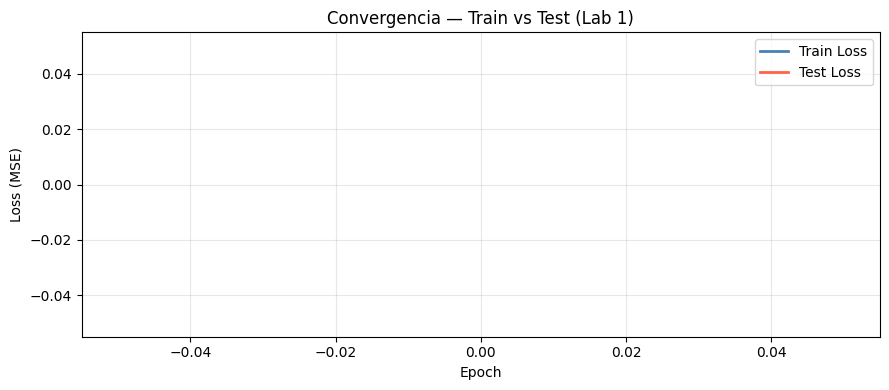

Train Loss final : nan
Test  Loss final : nan


In [13]:
# Grafica: Train Loss vs Test Loss por epoch
pyplot.figure(figsize=(9, 4))
pyplot.plot(train_losses,       color='steelblue', lw=2, label='Train Loss')
pyplot.plot(test_losses_epoch,  color='tomato',    lw=2, label='Test Loss')
pyplot.xlabel('Epoch')
pyplot.ylabel('Loss (MSE)')
pyplot.title('Convergencia — Train vs Test (Lab 1)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

print(f'Train Loss final : {train_losses[-1]:.4f}')
print(f'Test  Loss final : {test_losses_epoch[-1]:.4f}')
